In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.model_selection import GridSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Set Visualization Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Define Function to Parse XML Files
def parse_cdr_file(file_path):
    """
    Parse a CDR XML file and extract passages, annotations, and relations
    """
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    # Store data
    passages_data = []
    annotations_data = []
    relations_data = []
    
    for doc in root.findall('document'):
        doc_id = doc.find('id').text if doc.find('id') is not None else None
        
        # Extract passages
        for passage in doc.findall('passage'):
            passage_type = passage.find('infon[@key="type"]').text if passage.find('infon[@key="type"]') is not None else None
            text = passage.find('text').text if passage.find('text') is not None else ""
            offset = passage.find('offset').text if passage.find('offset') is not None else None
            
            passages_data.append({
                'doc_id': doc_id,
                'passage_type': passage_type,
                'offset': offset,
                'text': text
            })
        
        # Extract annotations
        for passage in doc.findall('passage'):
            for annotation in passage.findall('annotation'):
                ann_id = annotation.get('id')
                ann_type = annotation.find('infon[@key="type"]').text if annotation.find('infon[@key="type"]') is not None else None
                mesh_id = annotation.find('infon[@key="MESH"]').text if annotation.find('infon[@key="MESH"]') is not None else None
                text = annotation.find('text').text if annotation.find('text') is not None else None
                
                # Get location if available
                location = annotation.find('location')
                offset = location.get('offset') if location is not None else None
                length = location.get('length') if location is not None else None
                
                annotations_data.append({
                    'doc_id': doc_id,
                    'annotation_id': ann_id,
                    'type': ann_type,
                    'mesh_id': mesh_id,
                    'text': text,
                    'offset': offset,
                    'length': length
                })
        
        # Extract relations
        for relation in doc.findall('relation'):
            rel_id = relation.get('id')
            rel_type = relation.find('infon[@key="relation"]').text if relation.find('infon[@key="relation"]') is not None else None
            chemical_mesh = relation.find('infon[@key="Chemical"]').text if relation.find('infon[@key="Chemical"]') is not None else None
            disease_mesh = relation.find('infon[@key="Disease"]').text if relation.find('infon[@key="Disease"]') is not None else None
            
            relations_data.append({
                'doc_id': doc_id,
                'relation_id': rel_id,
                'relation_type': rel_type,
                'chemical_mesh': chemical_mesh,
                'disease_mesh': disease_mesh
            })
    
    # Create DataFrames
    df_passages = pd.DataFrame(passages_data)
    df_annotations = pd.DataFrame(annotations_data)
    df_relations = pd.DataFrame(relations_data)
    
    return df_passages, df_annotations, df_relations

print("Parser function defined successfully!")

Parser function defined successfully!


In [6]:
# Define file paths - UPDATE THESE WITH YOUR ACTUAL FILE PATHS
train_file = 'CDR_TrainingSet.BioC.xml'      # Replace with your training file
dev_file = 'CDR_DevelopmentSet.BioC.xml'      # Replace with your development file
test_file = 'CDR_TestSet.BioC.xml'            # Replace with your test file

print("Loading datasets...")

# Load training set
train_passages, train_annotations, train_relations = parse_cdr_file(train_file)
print(f"✓ Training set loaded: {len(train_passages)} passages, {len(train_annotations)} annotations, {len(train_relations)} relations")

# Load development set
dev_passages, dev_annotations, dev_relations = parse_cdr_file(dev_file)
print(f"✓ Development set loaded: {len(dev_passages)} passages, {len(dev_annotations)} annotations, {len(dev_relations)} relations")

# Load test set
test_passages, test_annotations, test_relations = parse_cdr_file(test_file)
print(f"✓ Test set loaded: {len(test_passages)} passages, {len(test_annotations)} annotations, {len(test_relations)} relations")

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'Documents':<12} {'Annotations':<15} {'Relations':<12}")
print("-"*60)
print(f"{'Training':<15} {train_passages['doc_id'].nunique():<12} {len(train_annotations):<15} {len(train_relations):<12}")
print(f"{'Development':<15} {dev_passages['doc_id'].nunique():<12} {len(dev_annotations):<15} {len(dev_relations):<12}")
print(f"{'Test':<15} {test_passages['doc_id'].nunique():<12} {len(test_annotations):<15} {len(test_relations):<12}")

Loading datasets...
✓ Training set loaded: 1000 passages, 9570 annotations, 1038 relations
✓ Development set loaded: 1000 passages, 9773 annotations, 1012 relations
✓ Test set loaded: 1000 passages, 9928 annotations, 1066 relations

DATASET SUMMARY
Dataset         Documents    Annotations     Relations   
------------------------------------------------------------
Training        500          9570            1038        
Development     500          9773            1012        
Test            500          9928            1066        


In [7]:
# Check annotation types in each dataset
print("\nANNOTATION TYPES DISTRIBUTION:")
print("="*60)

for name, annotations in [('Training', train_annotations), ('Development', dev_annotations), ('Test', test_annotations)]:
    print(f"\n{name} Set:")
    print(annotations['type'].value_counts().to_string())
    
# Check relation types
print("\n\nRELATION TYPES DISTRIBUTION:")
print("="*60)
for name, relations in [('Training', train_relations), ('Development', dev_relations), ('Test', test_relations)]:
    print(f"\n{name} Set:")
    if len(relations) > 0:
        print(relations['relation_type'].value_counts().to_string())
    else:
        print("No relations found")


ANNOTATION TYPES DISTRIBUTION:

Training Set:
type
Chemical    5207
Disease     4363

Development Set:
type
Chemical    5352
Disease     4421

Test Set:
type
Chemical    5394
Disease     4534


RELATION TYPES DISTRIBUTION:

Training Set:
relation_type
CID    1038

Development Set:
relation_type
CID    1012

Test Set:
relation_type
CID    1066


In [8]:
def create_samples(passages_df, annotations_df, relations_df, set_name):
    """
    Create positive and negative samples from a dataset
    """
    print(f"\nCreating samples for {set_name} set...")
    
    # Create a dictionary to store document text
    doc_text_dict = {}
    for doc_id in passages_df['doc_id'].unique():
        doc_text = ' '.join(passages_df[passages_df['doc_id'] == doc_id]['text'].tolist())
        doc_text_dict[doc_id] = doc_text
    
    # Create positive samples (from relations)
    positive_samples = []
    
    for _, row in relations_df.iterrows():
        doc_id = row['doc_id']
        chemical_mesh = row['chemical_mesh']
        disease_mesh = row['disease_mesh']
        
        # Get document text
        doc_text = doc_text_dict.get(doc_id, "")
        
        positive_samples.append({
            'doc_id': doc_id,
            'chemical_mesh': chemical_mesh,
            'disease_mesh': disease_mesh,
            'text': doc_text,
            'label': 1  # 1 means relation exists
        })
    
    print(f"  Positive samples: {len(positive_samples)}")
    
    # Create negative samples (randomly pair chemicals and diseases that are NOT in relations)
    # Get all unique chemicals and diseases from annotations
    chemicals = annotations_df[annotations_df['type'] == 'Chemical']['mesh_id'].unique()
    diseases = annotations_df[annotations_df['type'] == 'Disease']['mesh_id'].unique()
    
    # Create a set of existing relations
    existing_relations = set(zip(relations_df['chemical_mesh'], relations_df['disease_mesh']))
    
    # Create negative samples (same number as positive)
    import random
    random.seed(42)
    
    negative_samples = []
    attempts = 0
    max_attempts = len(positive_samples) * 10
    
    # Get list of all document IDs that have annotations
    doc_ids_with_annotations = annotations_df['doc_id'].unique()
    
    while len(negative_samples) < len(positive_samples) and attempts < max_attempts:
        # Randomly pick a document, chemical, and disease
        random_doc = random.choice(doc_ids_with_annotations)
        random_chem = random.choice(chemicals)
        random_disease = random.choice(diseases)
        
        # Check if this pair exists in relations
        if (random_chem, random_disease) not in existing_relations:
            # Get document text
            doc_text = doc_text_dict.get(random_doc, "")
            
            negative_samples.append({
                'doc_id': random_doc,
                'chemical_mesh': random_chem,
                'disease_mesh': random_disease,
                'text': doc_text,
                'label': 0  # 0 means no relation
            })
        
        attempts += 1
    
    print(f"  Negative samples: {len(negative_samples)}")
    print(f"  Total samples: {len(positive_samples) + len(negative_samples)}")
    
    # Combine positive and negative samples
    all_samples = positive_samples + negative_samples
    df_samples = pd.DataFrame(all_samples)
    
    return df_samples

# Create samples for each dataset
train_samples = create_samples(train_passages, train_annotations, train_relations, "TRAINING")
dev_samples = create_samples(dev_passages, dev_annotations, dev_relations, "DEVELOPMENT")
test_samples = create_samples(test_passages, test_annotations, test_relations, "TEST")

print("\n" + "="*60)
print("SAMPLES SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'Total Samples':<15} {'Positive':<12} {'Negative':<12}")
print("-"*60)
print(f"{'Training':<15} {len(train_samples):<15} {(train_samples['label']==1).sum():<12} {(train_samples['label']==0).sum():<12}")
print(f"{'Development':<15} {len(dev_samples):<15} {(dev_samples['label']==1).sum():<12} {(dev_samples['label']==0).sum():<12}")
print(f"{'Test':<15} {len(test_samples):<15} {(test_samples['label']==1).sum():<12} {(test_samples['label']==0).sum():<12}")


Creating samples for TRAINING set...
  Positive samples: 1038
  Negative samples: 1038
  Total samples: 2076

Creating samples for DEVELOPMENT set...
  Positive samples: 1012
  Negative samples: 1012
  Total samples: 2024

Creating samples for TEST set...
  Positive samples: 1066
  Negative samples: 1066
  Total samples: 2132

SAMPLES SUMMARY
Dataset         Total Samples   Positive     Negative    
------------------------------------------------------------
Training        2076            1038         1038        
Development     2024            1012         1012        
Test            2132            1066         1066        


In [9]:
def add_basic_features(df):
    """
    Add basic text features to the dataframe
    """
    # Fill NaN values
    df['text'] = df['text'].fillna('')
    
    # Feature 1: Text length
    df['text_length'] = df['text'].str.len()
    
    # Feature 2: Word count
    df['word_count'] = df['text'].str.split().str.len()
    
    # Feature 3: Average word length
    df['avg_word_length'] = df['text'].apply(
        lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
    )
    
    return df

# Add basic features to all datasets
train_samples = add_basic_features(train_samples)
dev_samples = add_basic_features(dev_samples)
test_samples = add_basic_features(test_samples)

print("Basic features added to all datasets")
print("\nFeature statistics (Training set):")
print(train_samples[['text_length', 'word_count', 'avg_word_length']].describe())

Basic features added to all datasets

Feature statistics (Training set):
       text_length   word_count  avg_word_length
count  2076.000000  2076.000000      2076.000000
mean   1334.125723   190.046724         6.102383
std     565.926305    83.630531         0.469993
min     322.000000    43.000000         4.785211
25%     874.000000   122.000000         5.797414
50%    1344.500000   193.000000         6.072917
75%    1755.000000   249.000000         6.355263
max    3538.000000   535.000000         8.133333


In [10]:
# IMPORTANT: Fit TF-IDF ONLY on training data to prevent data leakage
print("Creating TF-IDF features...")

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=100,  # Use top 100 features
                        stop_words='english',
                        ngram_range=(1, 2),  # Unigrams and bigrams
                        min_df=2,  # Ignore terms that appear in less than 2 documents
                        max_df=0.8)  # Ignore terms that appear in more than 80% of documents

# Fit on training data only
tfidf.fit(train_samples['text'])

# Transform all datasets
train_tfidf = tfidf.transform(train_samples['text'])
dev_tfidf = tfidf.transform(dev_samples['text'])
test_tfidf = tfidf.transform(test_samples['text'])

# Convert to DataFrames
tfidf_feature_names = [f'tfidf_{col}' for col in tfidf.get_feature_names_out()]
train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=tfidf_feature_names)
dev_tfidf_df = pd.DataFrame(dev_tfidf.toarray(), columns=tfidf_feature_names)
test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=tfidf_feature_names)

print(f"TF-IDF vocabulary size: {len(tfidf.get_feature_names_out())}")
print(f"Top TF-IDF features: {tfidf.get_feature_names_out()[:20]}")

Creating TF-IDF features...
TF-IDF vocabulary size: 100
Top TF-IDF features: ['10' '12' '15' '20' '30' '50' 'acid' 'activity' 'acute' 'administration'
 'adverse' 'associated' 'blood' 'cardiac' 'case' 'cases' 'caused'
 'changes' 'chronic' 'clinical']


In [11]:
# Combine basic features with TF-IDF features for each dataset
def combine_features(samples_df, tfidf_df):
    """
    Combine basic features with TF-IDF features
    """
    # Select basic features
    basic_features = samples_df[['label', 'text_length', 'word_count', 'avg_word_length']].reset_index(drop=True)
    
    # Combine with TF-IDF features
    combined = pd.concat([basic_features, tfidf_df.reset_index(drop=True)], axis=1)
    
    return combined

# Create final feature sets
train_features = combine_features(train_samples, train_tfidf_df)
dev_features = combine_features(dev_samples, dev_tfidf_df)
test_features = combine_features(test_samples, test_tfidf_df)

print(f"Training features shape: {train_features.shape}")
print(f"Development features shape: {dev_features.shape}")
print(f"Test features shape: {test_features.shape}")

Training features shape: (2076, 104)
Development features shape: (2024, 104)
Test features shape: (2132, 104)


In [12]:
# Separate features (X) and target (y)
X_train = train_features.drop('label', axis=1)
y_train = train_features['label']

X_dev = dev_features.drop('label', axis=1)
y_dev = dev_features['label']

X_test = test_features.drop('label', axis=1)
y_test = test_features['label']

print("FEATURE SETS SUMMARY:")
print("="*60)
print(f"{'Dataset':<15} {'Features':<12} {'Samples':<12} {'Positive':<12} {'Negative':<12}")
print("-"*60)
print(f"{'Training':<15} {X_train.shape[1]:<12} {len(y_train):<12} {(y_train==1).sum():<12} {(y_train==0).sum():<12}")
print(f"{'Development':<15} {X_dev.shape[1]:<12} {len(y_dev):<12} {(y_dev==1).sum():<12} {(y_dev==0).sum():<12}")
print(f"{'Test':<15} {X_test.shape[1]:<12} {len(y_test):<12} {(y_test==1).sum():<12} {(y_test==0).sum():<12}")

FEATURE SETS SUMMARY:
Dataset         Features     Samples      Positive     Negative    
------------------------------------------------------------
Training        103          2076         1038         1038        
Development     103          2024         1012         1012        
Test            103          2132         1066         1066        


In [13]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train)

# Transform all datasets
X_train_scaled = scaler.transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_dev_scaled = pd.DataFrame(X_dev_scaled, columns=X_dev.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Feature scaling complete!")
print(f"Training data after scaling - mean (should be ~0):")
print(X_train_scaled.mean().round(2).head())

Feature scaling complete!
Training data after scaling - mean (should be ~0):
text_length        0.0
word_count        -0.0
avg_word_length   -0.0
tfidf_10          -0.0
tfidf_12           0.0
dtype: float64


In [14]:
# Create and train logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Train on training data
log_reg.fit(X_train_scaled, y_train)

print("Model training complete!")
print(f"Number of features: {len(log_reg.coef_[0])}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")

Model training complete!
Number of features: 103
Intercept: -0.0017


In [15]:
# Predict on development set
y_dev_pred = log_reg.predict(X_dev_scaled)
y_dev_proba = log_reg.predict_proba(X_dev_scaled)[:, 1]

# Calculate metrics on development set
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
dev_precision = precision_score(y_dev, y_dev_pred)
dev_recall = recall_score(y_dev, y_dev_pred)
dev_f1 = f1_score(y_dev, y_dev_pred)
dev_roc_auc = roc_auc_score(y_dev, y_dev_proba)

print("="*60)
print("MODEL PERFORMANCE ON DEVELOPMENT SET")
print("="*60)
print(f"Accuracy:  {dev_accuracy:.4f}  ({dev_accuracy*100:.2f}%)")
print(f"Precision: {dev_precision:.4f}  ({dev_precision*100:.2f}%)")
print(f"Recall:    {dev_recall:.4f}  ({dev_recall*100:.2f}%)")
print(f"F1-Score:  {dev_f1:.4f}  ({dev_f1*100:.2f}%)")
print(f"ROC-AUC:   {dev_roc_auc:.4f}  ({dev_roc_auc*100:.2f}%)")
print("="*60)

MODEL PERFORMANCE ON DEVELOPMENT SET
Accuracy:  0.5163  (51.63%)
Precision: 0.5163  (51.63%)
Recall:    0.5178  (51.78%)
F1-Score:  0.5170  (51.70%)
ROC-AUC:   0.5226  (52.26%)


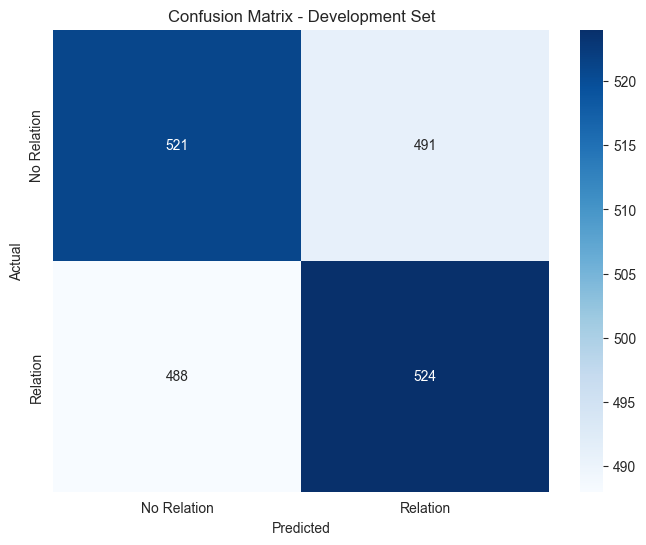

Confusion Matrix Interpretation:
True Negatives: 521 - Correctly predicted NO relation
False Positives: 491 - Wrongly predicted relation
False Negatives: 488 - Missed actual relations
True Positives: 524 - Correctly predicted relations


In [16]:
# Confusion matrix for development set
cm_dev = confusion_matrix(y_dev, y_dev_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dev, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Relation', 'Relation'],
            yticklabels=['No Relation', 'Relation'])
plt.title('Confusion Matrix - Development Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("Confusion Matrix Interpretation:")
print(f"True Negatives: {cm_dev[0,0]} - Correctly predicted NO relation")
print(f"False Positives: {cm_dev[0,1]} - Wrongly predicted relation")
print(f"False Negatives: {cm_dev[1,0]} - Missed actual relations")
print(f"True Positives: {cm_dev[1,1]} - Correctly predicted relations")

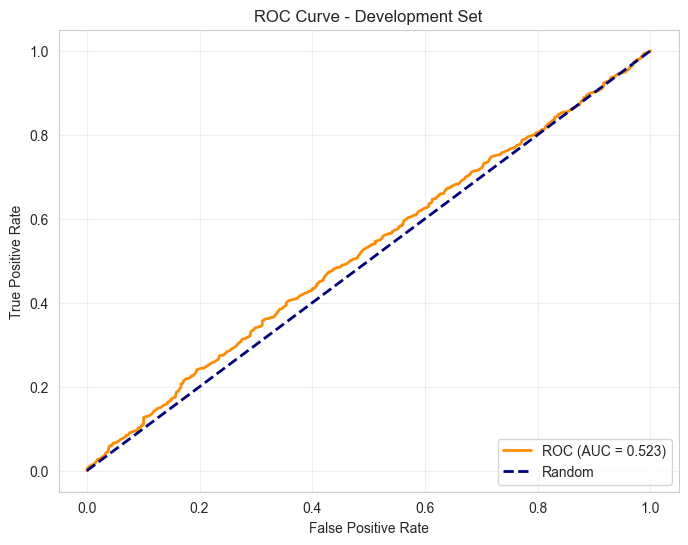

Optimal threshold: 0.540
At threshold 0.540: TPR=0.400, FPR=0.354


In [17]:
# Calculate ROC curve for development set
fpr_dev, tpr_dev, thresholds_dev = roc_curve(y_dev, y_dev_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dev, tpr_dev, color='darkorange', lw=2, label=f'ROC (AUC = {dev_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Development Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Find optimal threshold
optimal_idx = np.argmax(tpr_dev - fpr_dev)
optimal_threshold = thresholds_dev[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"At threshold {optimal_threshold:.3f}: TPR={tpr_dev[optimal_idx]:.3f}, FPR={fpr_dev[optimal_idx]:.3f}")

In [18]:
# Define hyperparameters to tune
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Create grid search
grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
                           param_grid, cv=3, scoring='f1', verbose=1, n_jobs=-1)

# Fit on training data
print("Performing grid search (this may take a minute)...")
grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

# Use best model
best_model = grid_search.best_estimator_

# Evaluate on development set
y_dev_pred_best = best_model.predict(X_dev_scaled)
y_dev_proba_best = best_model.predict_proba(X_dev_scaled)[:, 1]

dev_f1_best = f1_score(y_dev, y_dev_pred_best)
print(f"\nDevelopment set F1 with best model: {dev_f1_best:.4f}")

Performing grid search (this may take a minute)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters found:
{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation F1 score: 0.4086

Development set F1 with best model: 0.5294



MODEL PERFORMANCE COMPARISON ACROSS DATASETS
    dataset  accuracy  precision   recall       f1  roc_auc
   Training  0.593449   0.591337 0.605010 0.598095 0.632986
Development  0.509881   0.509124 0.551383 0.529412 0.524328
       Test  0.518293   0.516710 0.565666 0.540081 0.544320


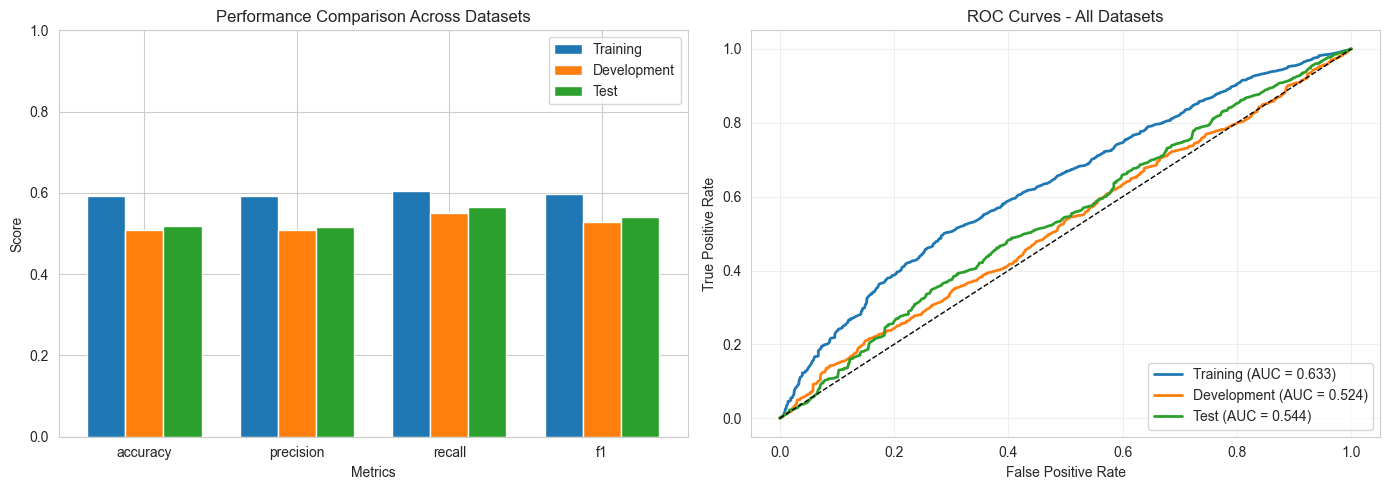

In [19]:
# Evaluate best model on all datasets
def evaluate_model(model, X, y, dataset_name):
    """
    Evaluate model and return metrics
    """
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    return {
        'dataset': dataset_name,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_proba)
    }

# Evaluate on all three sets
train_metrics = evaluate_model(best_model, X_train_scaled, y_train, 'Training')
dev_metrics = evaluate_model(best_model, X_dev_scaled, y_dev, 'Development')
test_metrics = evaluate_model(best_model, X_test_scaled, y_test, 'Test')

# Create comparison DataFrame
comparison_df = pd.DataFrame([train_metrics, dev_metrics, test_metrics])
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON ACROSS DATASETS")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparison
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (idx, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=row['dataset'])

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison Across Datasets')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim([0, 1])

# Plot 2: ROC curves comparison
for i, (X, y, name) in enumerate([(X_train_scaled, y_train, 'Training'),
                                  (X_dev_scaled, y_dev, 'Development'),
                                  (X_test_scaled, y_test, 'Test')]):
    y_proba = best_model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc = roc_auc_score(y, y_proba)
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - All Datasets')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TOP 20 MOST IMPORTANT FEATURES:
         feature  coefficient
        tfidf_mg     0.123190
  tfidf_receptor     0.089350
  tfidf_syndrome     0.074896
     text_length     0.074232
   tfidf_results     0.070853
  tfidf_received     0.064965
    tfidf_caused     0.059492
    tfidf_report     0.045657
  tfidf_patients     0.043991
  tfidf_reported     0.042922
  tfidf_toxicity     0.040915
   tfidf_cardiac     0.037937
      tfidf_pain     0.037394
 tfidf_hepatitis     0.029357
tfidf_associated     0.028398
    tfidf_showed     0.027468
  tfidf_response     0.027442
       tfidf_old     0.024013
     tfidf_renal     0.020809
     tfidf_acute     0.018833

TOP 20 LEAST IMPORTANT FEATURES:
            feature  coefficient
       tfidf_severe    -0.010808
         tfidf_rate    -0.013885
    tfidf_increased    -0.015010
    tfidf_treatment    -0.016800
           tfidf_30    -0.018330
           tfidf_50    -0.022392
      tfidf_chronic    -0.022756
        tfidf_doses    -0.026145
       

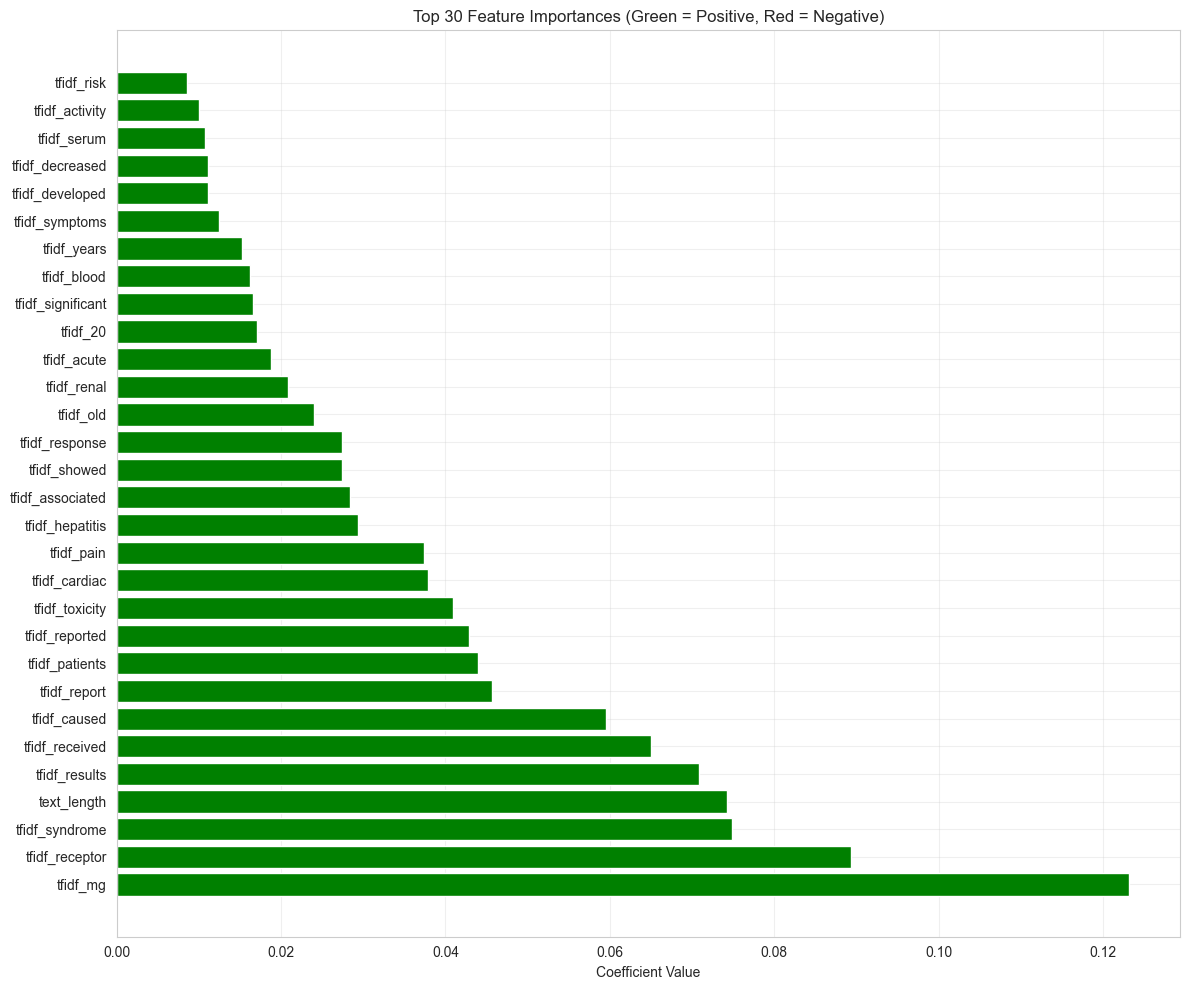

In [20]:
# Get feature coefficients
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("TOP 20 MOST IMPORTANT FEATURES:")
print("="*60)
print(feature_importance.head(20).to_string(index=False))

print("\nTOP 20 LEAST IMPORTANT FEATURES:")
print("="*60)
print(feature_importance.tail(20).to_string(index=False))

# Visualize top features
plt.figure(figsize=(12, 10))
top_features = feature_importance.head(30)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 30 Feature Importances (Green = Positive, Red = Negative)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

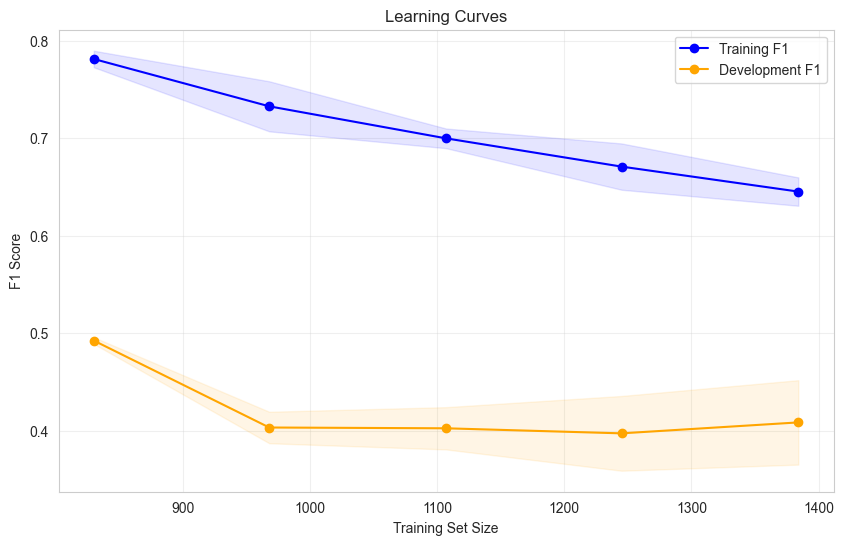

Learning Curve Interpretation:
⚠️ Model is overfitting (large gap between training and development)


In [21]:
from sklearn.model_selection import learning_curve

# Generate learning curves
train_sizes, train_scores, dev_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=3, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1', n_jobs=-1
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
dev_mean = np.mean(dev_scores, axis=1)
dev_std = np.std(dev_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, dev_mean - dev_std, dev_mean + dev_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
plt.plot(train_sizes, dev_mean, 'o-', color='orange', label='Development F1')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print("Learning Curve Interpretation:")
if train_mean[-1] - dev_mean[-1] > 0.1:
    print("⚠️ Model is overfitting (large gap between training and development)")
elif train_mean[-1] < 0.7:
    print("⚠️ Model is underfitting (low training performance)")
else:
    print("✅ Model shows good fit (reasonable gap and good performance)")


FINAL MODEL EVALUATION ON TEST SET

Metric               Score      Percentage  
--------------------------------------------------
Accuracy             0.5183      51.83%
Precision            0.5167      51.67%
Recall               0.5657      56.57%
F1-Score             0.5401      54.01%
ROC-AUC              0.5443      54.43%


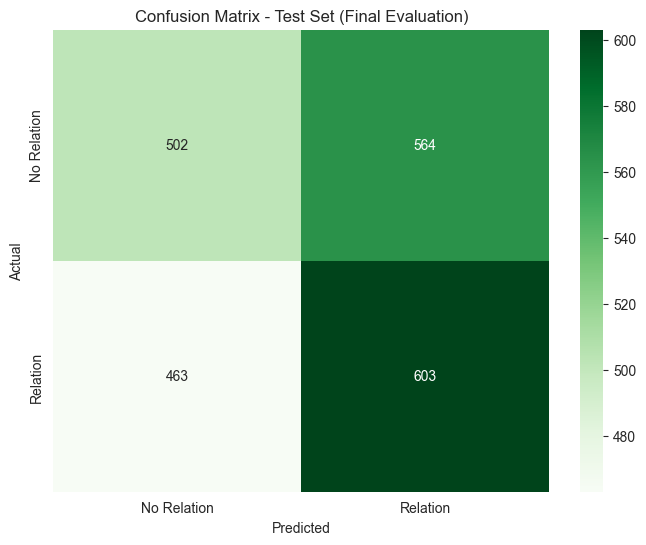


Detailed Classification Report:
              precision    recall  f1-score   support

 No Relation       0.52      0.47      0.49      1066
    Relation       0.52      0.57      0.54      1066

    accuracy                           0.52      2132
   macro avg       0.52      0.52      0.52      2132
weighted avg       0.52      0.52      0.52      2132



In [22]:
print("\n" + "="*70)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*70)

# Predict on test set
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n{'Metric':<20} {'Score':<10} {'Percentage':<12}")
print("-"*50)
print(f"{'Accuracy':<20} {test_accuracy:.4f}      {test_accuracy*100:.2f}%")
print(f"{'Precision':<20} {test_precision:.4f}      {test_precision*100:.2f}%")
print(f"{'Recall':<20} {test_recall:.4f}      {test_recall*100:.2f}%")
print(f"{'F1-Score':<20} {test_f1:.4f}      {test_f1*100:.2f}%")
print(f"{'ROC-AUC':<20} {test_roc_auc:.4f}      {test_roc_auc*100:.2f}%")

# Confusion matrix for test set
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Relation', 'Relation'],
            yticklabels=['No Relation', 'Relation'])
plt.title('Confusion Matrix - Test Set (Final Evaluation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Relation', 'Relation']))